# Read training data of forcesmip6 challenge

In [1]:
import os
import netCDF4 as netcdf
import numpy as np
import sys
maindir = os.getcwd()
sys.path.append(maindir+"/ForceSMIP")

PATH = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP/Training-Ext/Amon/tas'

In [2]:
DIR_LIST = os.listdir(PATH)

dic_data = {}
dic_forced_response = {}

# how to center the data with respect to the monthly mean

# 1. calculate the monthly mean
# 2. subtract the monthly mean from the data
# 3. calculate the forced response by averaging over the time dimension

for idx_m, dir in enumerate(DIR_LIST):

    print(f'Processing {idx_m+1}/{len(DIR_LIST)}: {dir}')
    dir_path = os.path.join(PATH, dir)
    file_list = os.listdir(dir_path)

    dic_data[dir] = np.zeros((len(file_list), 2652, 72, 144), dtype=np.float32)
    dic_forced_response[dir] = np.zeros((len(file_list), 2652, 72, 144), dtype=np.float32)

    for idx_f, file in enumerate(file_list):
        print(f'  Processing {idx_f+1}/{len(file_list)}: {file}')
        file_path = os.path.join(dir_path, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')

        # set variables
        time = np.array(netcdf_file.variables['time'][:])
        longitude = np.array(netcdf_file.variables['lon'][:])
        latitude = np.array(netcdf_file.variables['lat'][:])
        dic_data[dir][idx_f,:,:,:] = np.array(netcdf_file.variables['tas']) 
        for i in range(12):
            dic_data[dir][idx_f,np.arange(time.shape[0]) % 12 == i,:,:] = dic_data[dir][idx_f,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(dic_data[dir][idx_f, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)

        # print(f'  Tas shape: {tas.shape}')
    dic_forced_response[dir][:,:,:,:] = np.nanmean(dic_data[dir], axis=0)
    


Processing 1/5: CESM2
  Processing 1/50: tas_mon_CESM2_historical_ssp370_r1251.013i1p1f1.188001-210012.nc
  Processing 2/50: tas_mon_CESM2_historical_ssp370_r1011.001i1p1f1.188001-210012.nc
  Processing 3/50: tas_mon_CESM2_historical_ssp370_r1251.015i1p1f1.188001-210012.nc
  Processing 4/50: tas_mon_CESM2_historical_ssp370_r1031.002i1p1f1.188001-210012.nc
  Processing 5/50: tas_mon_CESM2_historical_ssp370_r1251.014i1p1f1.188001-210012.nc
  Processing 6/50: tas_mon_CESM2_historical_ssp370_r1051.003i1p1f1.188001-210012.nc
  Processing 7/50: tas_mon_CESM2_historical_ssp370_r1251.016i1p1f1.188001-210012.nc
  Processing 8/50: tas_mon_CESM2_historical_ssp370_r1071.004i1p1f1.188001-210012.nc
  Processing 9/50: tas_mon_CESM2_historical_ssp370_r1251.017i1p1f1.188001-210012.nc
  Processing 10/50: tas_mon_CESM2_historical_ssp370_r1091.005i1p1f1.188001-210012.nc
  Processing 11/50: tas_mon_CESM2_historical_ssp370_r1251.018i1p1f1.188001-210012.nc
  Processing 12/50: tas_mon_CESM2_historical_ssp370_

# Get Test data in Evaluation Tier1 

In [3]:
# read the test data
PATH_EVAL = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/Evaluation-Tier1/'

lst_test_name = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']
lst_test_name = ['B', 'D', 'E', 'G','J']

DIR_LIST_TEST = os.listdir(PATH_EVAL)
data_test = np.zeros((len(lst_test_name), 876, 72, 144), dtype=np.float32)



for idx_r, file in enumerate(DIR_LIST_TEST):

    if file.startswith('tas_') and file.endswith('.nc'):
        print(f'  Processing {idx_r+1}/{len(DIR_LIST_TEST)}: {file}')
        file_path = os.path.join(PATH_EVAL, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')

        # set variables
        time = np.array(netcdf_file.variables['time'])
        longitude = np.array(netcdf_file.variables['lon'])
        latitude = np.array(netcdf_file.variables['lat'])

        if file[9] in lst_test_name:
            # find position of file[9] in lst_test_name
            idx_test = lst_test_name.index(file[9])
            print(f'  Found test data for {file[9]} at index {idx_test}')
            data_test[idx_test,:,:,:] = np.array(netcdf_file.variables['tas']) 
        
            for i in range(12):
                data_test[idx_test,np.arange(time.shape[0]) % 12 == i,:,:] = data_test[idx_test,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(data_test[idx_test, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)

            print(f'  Tas shape: {data_test[idx_test,:,:,:].shape}')

  Processing 6/81: tas_mon_1F.195001-202212.nc
  Processing 12/81: tas_mon_1C.195001-202212.nc
  Processing 16/81: tas_mon_1H.195001-202212.nc
  Processing 26/81: tas_mon_1G.195001-202212.nc
  Found test data for G at index 3
  Tas shape: (876, 72, 144)
  Processing 40/81: tas_mon_1D.195001-202212.nc
  Found test data for D at index 1
  Tas shape: (876, 72, 144)
  Processing 52/81: tas_mon_1J.195001-202212.nc
  Found test data for J at index 4
  Tas shape: (876, 72, 144)
  Processing 58/81: tas_mon_1A.195001-202212.nc
  Processing 60/81: tas_mon_1E.195001-202212.nc
  Found test data for E at index 2
  Tas shape: (876, 72, 144)
  Processing 71/81: tas_mon_1B.195001-202212.nc
  Found test data for B at index 0
  Tas shape: (876, 72, 144)
  Processing 77/81: tas_mon_1I.195001-202212.nc


In [4]:
# Read the ground truth data

PATH_GROUND_TRUTH = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/ensmeans-Tier1'

DIR_LIST_GROUND_TRUTH = os.listdir(PATH_GROUND_TRUTH)

data_ground_truth_test = np.zeros((len(lst_test_name), 876, 72, 144), dtype=np.float32)

for idx_r, file in enumerate(DIR_LIST_GROUND_TRUTH):

    if file.__contains__('.tas.'):
        
        print(f'  Processing {idx_r+1}: {file}')

        # read the ground truth data
        file_path = os.path.join(PATH_GROUND_TRUTH, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')

        # set variables
        time = np.array(netcdf_file.variables['time'])
        longitude = np.array(netcdf_file.variables['lon'])
        latitude = np.array(netcdf_file.variables['lat'])

        if file[1] in lst_test_name:
            # find position of file[1] in lst_test_name
            idx_test = lst_test_name.index(file[1])
            print(f'  Found test data for {file[1]} at index {idx_test}')
            data_ground_truth_test[idx_test,:,:,:] = np.array(netcdf_file.variables['arr_EM'])

            for i in range(12):
                data_ground_truth_test[idx_test,np.arange(time.shape[0]) % 12 == i,:,:] = data_ground_truth_test[idx_test,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(data_ground_truth_test[idx_test, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)

            print(f'  Tas shape: {data_ground_truth_test[idx_test,:,:,:].shape}')

  Processing 7: 1A.tas.EM.1950-2022.nc
  Processing 15: 1B.tas.EM.1950-2022.nc
  Found test data for B at index 0
  Tas shape: (876, 72, 144)
  Processing 23: 1C.tas.EM.1950-2022.nc
  Processing 31: 1D.tas.EM.1950-2022.nc
  Found test data for D at index 1
  Tas shape: (876, 72, 144)
  Processing 39: 1E.tas.EM.1950-2022.nc
  Found test data for E at index 2
  Tas shape: (876, 72, 144)
  Processing 47: 1F.tas.EM.1950-2022.nc
  Processing 55: 1G.tas.EM.1950-2022.nc
  Found test data for G at index 3
  Tas shape: (876, 72, 144)
  Processing 63: 1H.tas.EM.1950-2022.nc
  Processing 71: 1J.tas.EM.1950-2022.nc
  Found test data for J at index 4
  Tas shape: (876, 72, 144)


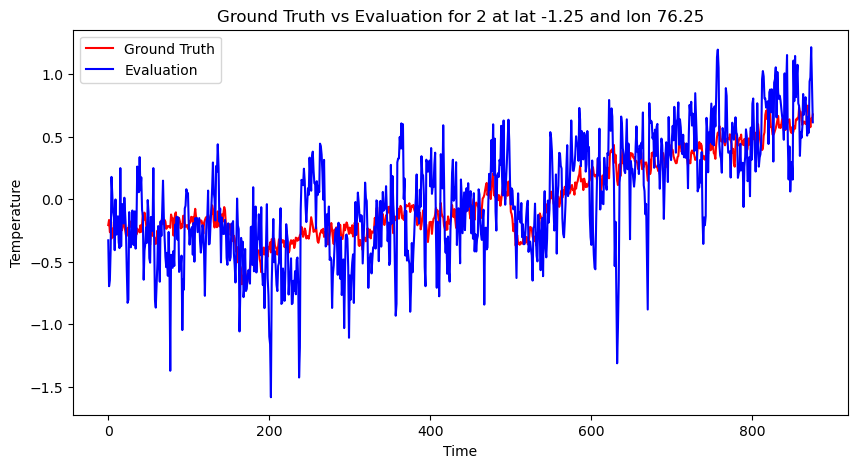

In [5]:
# check if the data is correct by plotting the ensemble mean and the evaluation data on the same plot
import matplotlib.pyplot as plt

idx_run = 2
idx_lat = 35
idx_lon = 30

x_tmp = data_ground_truth_test[idx_run,:,idx_lat,idx_lon]
y_tmp = data_test[idx_run,:,idx_lat,idx_lon]

plt.figure(figsize=(10, 5))
plt.plot(x_tmp, label='Ground Truth', color='red')
plt.plot(y_tmp, label='Evaluation', color='blue')
plt.title(f'Ground Truth vs Evaluation for {idx_run} at lat {latitude[idx_lat]} and lon {longitude[idx_lon]}')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.show()

# Merge training data to train the ridge regression model

In [6]:
import torch

def normalize_data(data, means, vars):
    """Normalize the data with respect to the monthly mean and the variance of the anomaly.
       Args:
           data: numpy array of shape (runs, time steps, latitude, longitude)
           means: numpy array of shape (runs, latitude, longitude)
           vars: numpy array of shape (runs, latitude, longitude)
       Return:
           normalized_data: numpy array of shape (runs, time steps, latitude, longitude)
    """
    normalized_data = {}
    for idx,key in enumerate(data.keys()):
        normalized_data[key] = (data[key] - means[key]) / np.sqrt(vars[key])
    return normalized_data

def merge_training_data(x,y,dtype=torch.float32):
    """Concatenate training sets for all models except model m. This enables to create the big matrices X and Y.
        Unnormalized data.
       Args:

       Return:
    """
    ################ We construct X, Y in R^{grid x runs*time steps}

    # Concatenate all models to build the matrix X
    
    for idx_m,m in enumerate(x.keys()):
        
        if idx_m ==0:

            x_train = torch.from_numpy(x[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0])/torch.sqrt(torch.tensor(x[m].shape[0]))
            y_train = torch.from_numpy(y[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0])/torch.sqrt(torch.tensor(x[m].shape[0]))


        else:
            x_train = torch.cat([x_train, torch.from_numpy(x[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0]) /torch.sqrt(torch.tensor(x[m].shape[0]))],dim=0)
            y_train = torch.cat([y_train, torch.from_numpy(y[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0]) /torch.sqrt(torch.tensor(x[m].shape[0]))],dim=0)

        print(f'  x_train shape: {x_train.shape}')
    return x_train, y_train


def reshape_training_data(x,y,dtype=torch.float32):
    """Concatenate training sets for all models except model m. This enables to create the big matrices X and Y.
        Unnormalized data.
       Args:

       Return:
    """
    ################ We construct X, Y in R^{grid x runs*time steps}

    # Concatenate all models to build the matrix X
    x_train = {}
    y_train = {}
    
    for idx_m,m in enumerate(x.keys()):
        
        x_train[m] = torch.from_numpy(x[m]).to(torch.float32).reshape(x[m].shape[0],x[m].shape[1],longitude.shape[0]*latitude.shape[0])
        y_train[m] = torch.from_numpy(y[m]).to(torch.float32).reshape(x[m].shape[0],x[m].shape[1],longitude.shape[0]*latitude.shape[0])
        print(f'  x_train shape: {x_train[m].shape}')
        print(f'  y_train shape: {y_train[m].shape}')
    return x_train, y_train

In [7]:
def yearly_average(x, months_per_year=12):
    """
    Compute the yearly average of a time series.
    Args:
        data: numpy array of shape (time, ...)
        months_per_year: int, number of months in a year (default: 12)
    Returns:
        numpy array of shape (years, ...)
    """
    n_years = x.shape[1] // months_per_year
    data_reshaped = x.reshape(x.shape[0],n_years, months_per_year, x.shape[2],x.shape[3])
    return data_reshaped.mean(axis=2)


# Compute the yearly average for each key in the dictionary
def compute_yearly_average(data, months_per_year=12):
    """
    Compute the yearly average of a dictionary of numpy arrays.
    Args:
        data: dictionary of numpy arrays
        months_per_year: int, number of months in a year (default: 12)
    Returns:
        dictionary of numpy arrays with yearly averages
    """
    yearly_data = {}
    for key, m in enumerate(data.keys()):
        yearly_data[m] = yearly_average(data[m], months_per_year)

    return yearly_data

In [8]:
from preprocessing import stack_models_and_runs

# compute training set and test set
x_train, y_train  = merge_training_data(dic_data,dic_forced_response,dtype=torch.float32)
x, y = reshape_training_data(dic_data,dic_forced_response,dtype=torch.float32)


  x_train shape: torch.Size([132600, 10368])
  x_train shape: torch.Size([198900, 10368])
  x_train shape: torch.Size([278460, 10368])
  x_train shape: torch.Size([411060, 10368])
  x_train shape: torch.Size([490620, 10368])
  x_train shape: torch.Size([50, 2652, 10368])
  y_train shape: torch.Size([50, 2652, 10368])
  x_train shape: torch.Size([25, 2652, 10368])
  y_train shape: torch.Size([25, 2652, 10368])
  x_train shape: torch.Size([30, 2652, 10368])
  y_train shape: torch.Size([30, 2652, 10368])
  x_train shape: torch.Size([50, 2652, 10368])
  y_train shape: torch.Size([50, 2652, 10368])
  x_train shape: torch.Size([30, 2652, 10368])
  y_train shape: torch.Size([30, 2652, 10368])


# Get the estimates of the other methods

In [9]:
# Read the estimates of the other methods
# read the test data
PATH_TEST = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/ForceSMIP-estimates-Tier1'

DIR_LIST_TEST = os.listdir(PATH_TEST)
data_estimates = np.zeros((30,len(lst_test_name), 876, 72, 144), dtype=np.float32)


for idx_r, file in enumerate(DIR_LIST_TEST):

    if file.startswith('tas_'):

        # read the test data
        print(f'  Processing {idx_r+1}/{len(DIR_LIST_TEST)}: {file}')
        file_path = os.path.join(PATH_TEST, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')


        # set variables
        time = np.array(netcdf_file.variables['time'])
        longitude = np.array(netcdf_file.variables['lon'])
        latitude = np.array(netcdf_file.variables['lat'])

        if file[5] in lst_test_name:
            # find position of file[1] in lst_test_name
            idx_test = lst_test_name.index(file[5])
            print(f'  Found test data for {file[5]} at index {idx_test}')
            data_estimates[:,idx_test,:,:,:] = np.array(netcdf_file.variables['forced_component']) 

        print(f'  Tas shape: {data_estimates[:,idx_test,:,:,:].shape}')

lst_to_center = [8,9,14,24]

# center the methods that are not centered
for idx_m in lst_to_center:
    print(f'Centering data for method {idx_m}')
    for i in range(12):
        data_estimates[idx_m,:,np.arange(time.shape[0]) % 12 == i,:,:] = data_estimates[idx_m,:,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(data_estimates[idx_m,:, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)


  Processing 51/80: tas_1A_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 52/80: tas_1B_1950_2022.nc
  Found test data for B at index 0
  Tas shape: (30, 876, 72, 144)
  Processing 53/80: tas_1C_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 54/80: tas_1D_1950_2022.nc
  Found test data for D at index 1
  Tas shape: (30, 876, 72, 144)
  Processing 55/80: tas_1E_1950_2022.nc
  Found test data for E at index 2


  Tas shape: (30, 876, 72, 144)
  Processing 56/80: tas_1F_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 57/80: tas_1G_1950_2022.nc
  Found test data for G at index 3
  Tas shape: (30, 876, 72, 144)
  Processing 58/80: tas_1H_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 59/80: tas_1I_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 60/80: tas_1J_1950_2022.nc
  Found test data for J at index 4
  Tas shape: (30, 876, 72, 144)
Centering data for method 8
Centering data for method 9
Centering data for method 14
Centering data for method 24


In [10]:
# compute mse of the other estimates
mse_estimates = np.zeros((data_estimates.shape[0],data_estimates.shape[1]))

for idx_r in range(data_estimates.shape[0]):
    mse_estimates[idx_r,:] = np.sqrt(np.mean((data_estimates[idx_r,:,:,:,:] - data_ground_truth_test) ** 2,axis=(1,2,3)))
     
    print(f'  MSE estimates: {mse_estimates[idx_r,:]}')

# mse_estimates[:,8] = 0.0

  MSE estimates: [0.51100057 0.84101903 0.48415652 0.61143172 0.51178229]
  MSE estimates: [0.5460459  0.7674492  0.49941075 0.57887173 0.59348494]
  MSE estimates: [0.5012449  0.87728935 0.48170397 0.55289179 0.57025641]
  MSE estimates: [0.56283027 0.44237232 0.5036909  0.49771696 0.48009971]
  MSE estimates: [0.43215752 0.59834325 0.44574437 0.52151704 0.47624314]
  MSE estimates: [0.38175088 0.45852318 0.4024646  0.47676918 0.43520856]
  MSE estimates: [0.41481045 0.73331398 0.422548   0.50368208 0.43823734]
  MSE estimates: [0.50437868 0.77526796 0.50779128 0.59402609 0.58185816]
  MSE estimates: [0.37813792 0.48652285 0.39246643 0.46206051 0.42798257]
  MSE estimates: [0.9591617  1.10822606 0.92971539 1.0059222  1.00002348]
  MSE estimates: [0.52847624 0.87159228 0.50417084 0.60457903 0.61417121]
  MSE estimates: [0.41384193 0.64842671 0.40689006 0.52918929 0.44698444]
  MSE estimates: [0.4138484  0.64830804 0.41276166 0.52479839 0.44505617]
  MSE estimates: [0.40755942 0.6882101

  MSE estimates: [0.45433953 0.43375766 0.49814174 0.44377398 0.51943386]
  MSE estimates: [0.44899049 0.44527581 0.61208522 0.49237496 0.59934628]
  MSE estimates: [0.4057453  0.70722187 0.40380749 0.48665681 0.4305158 ]
  MSE estimates: [0.42906636 0.74852276 0.44161707 0.53212947 0.46590745]
  MSE estimates: [0.41185108 0.76128298 0.4142566  0.50310254 0.44601616]
  MSE estimates: [0.50023407 0.82582235 0.55010921 0.56967407 0.51360339]
  MSE estimates: [0.36789382 0.50839216 0.37918019 0.47166604 0.43057039]


# Yearly data

In [11]:
# Train the model on the yearly data
dic_data_yearly = compute_yearly_average(dic_data , months_per_year=12)
dic_forced_response_yearly = compute_yearly_average(dic_forced_response, months_per_year=12)

# Reshape the data to have the shape (runs, years, latitude * longitude)
x_test = data_test.reshape(data_test.shape[0], data_test.shape[1], longitude.shape[0]*latitude.shape[0])
y_test = data_ground_truth_test.reshape(data_ground_truth_test.shape[0], data_ground_truth_test.shape[1], longitude.shape[0]*latitude.shape[0])

x_test_yearly = yearly_average(data_test, months_per_year=12)
x_test_yearly = x_test_yearly.reshape(x_test_yearly.shape[0], x_test_yearly.shape[1], longitude.shape[0]*latitude.shape[0])
x_test_yearly_torch = torch.from_numpy(x_test_yearly).to(torch.float32)

y_test_yearly = yearly_average(data_ground_truth_test, months_per_year=12)
y_test_yearly = y_test_yearly.reshape(y_test_yearly.shape[0], y_test_yearly.shape[1], longitude.shape[0]*latitude.shape[0])
y_test_yearly_torch = torch.from_numpy(y_test_yearly).to(torch.float32)

data_estimates_yearly = np.zeros((data_estimates.shape[0], data_estimates.shape[1], data_estimates.shape[2]//12, 72, 144), dtype=np.float32)
for idx_m in range(data_estimates.shape[0]):
    data_estimates_yearly[idx_m,:,:,:,:] = yearly_average(data_estimates[idx_m,:,:,:], months_per_year=12)

data_estimates_yearly_torch =  torch.from_numpy(data_estimates_yearly).reshape(data_estimates_yearly.shape[0], data_estimates_yearly.shape[1], data_estimates_yearly.shape[2], -1)

In [12]:
# compute the yearly mse of the other estimates 
# compute mse of the other estimates
mse_estimates_yearly = np.zeros((data_estimates.shape[0],data_estimates.shape[1]))

for idx_r in range(data_estimates.shape[0]):
    mse_estimates_yearly[idx_r,:] = np.sqrt(np.mean((data_estimates_yearly[idx_r,:,:,:,:] - y_test_yearly.reshape(y_test_yearly.shape[0],y_test_yearly.shape[1],latitude.shape[0],longitude.shape[0])) ** 2,axis=(1,2,3))) 
    print(f'  MSE estimates: {mse_estimates_yearly[idx_r,:]}')

# mse_estimates_yearly[:,8] = 0.0

  MSE estimates: [0.3708767  0.76184803 0.32120651 0.42573875 0.36297438]
  MSE estimates: [0.31422687 0.57667619 0.24059433 0.3127341  0.30820149]
  MSE estimates: [0.27296612 0.70761365 0.23452061 0.29515049 0.27288583]
  MSE estimates: [0.41958332 0.26345435 0.33542052 0.28473562 0.28350335]
  MSE estimates: [0.22750515 0.46762332 0.23152888 0.25804055 0.26351762]
  MSE estimates: [0.19806424 0.31416944 0.21652955 0.24898265 0.2441894 ]
  MSE estimates: [0.21705036 0.63489521 0.20965408 0.24261999 0.24459068]
  MSE estimates: [0.27461651 0.60792452 0.25935444 0.32759362 0.39957711]
  MSE estimates: [0.19176921 0.34745461 0.20301221 0.22336519 0.23584743]
  MSE estimates: [0.39808676 0.61394781 0.35952675 0.41795275 0.38969341]
  MSE estimates: [0.30238605 0.72864836 0.26559502 0.36354282 0.31569293]
  MSE estimates: [0.21946199 0.54224259 0.18590359 0.29149708 0.26371101]
  MSE estimates: [0.21665739 0.54131752 0.19710793 0.28298753 0.26177433]
  MSE estimates: [0.20829439 0.5897602

In [13]:
# train the models on yearly data
# compute training set and test set

x_train_yearly, y_train_yearly  = merge_training_data(dic_data_yearly,dic_forced_response_yearly,dtype=torch.float32)
x_yearly, y_yearly = reshape_training_data(dic_data_yearly,dic_forced_response_yearly,dtype=torch.float32)

  x_train shape: torch.Size([11050, 10368])
  x_train shape: torch.Size([16575, 10368])
  x_train shape: torch.Size([23205, 10368])
  x_train shape: torch.Size([34255, 10368])
  x_train shape: torch.Size([40885, 10368])
  x_train shape: torch.Size([50, 221, 10368])
  y_train shape: torch.Size([50, 221, 10368])
  x_train shape: torch.Size([25, 221, 10368])
  y_train shape: torch.Size([25, 221, 10368])
  x_train shape: torch.Size([30, 221, 10368])
  y_train shape: torch.Size([30, 221, 10368])
  x_train shape: torch.Size([50, 221, 10368])
  y_train shape: torch.Size([50, 221, 10368])
  x_train shape: torch.Size([30, 221, 10368])
  y_train shape: torch.Size([30, 221, 10368])


# Construct the dataset with a time index feature

In [14]:
### Training dates 
years_train = np.arange(2100 - 1880 +1)

# year index to a scalar in [0,1]
years_train_idx_feature = years_train   # normalize to [0,1] range

# get index of years 1950 - 2022
years_test = years_train[(years_train >= 1950-1880) & (years_train <= 2022-1880)]
years_test_idx_feature =  years_test

In [15]:
import torch.nn.functional as F

def moving_average_smoothing(x, window_size=5, mode='same'):
    """
    Apply moving average smoothing to multivariate time series using PyTorch.
    
    Args:
        x: torch.Tensor of shape (n_samples, n_timesteps, n_features)
           where first dimension is number of samples, second is time, third is features
        window_size: int, size of the moving average window
        mode: str, padding mode - 'same' keeps original length, 'valid' reduces length
    
    Returns:
        smoothed_x: torch.Tensor of same shape as input (if mode='same') or reduced size
    """
    n_samples, n_timesteps, n_features = x.shape
    
    # Create uniform kernel for moving average
    kernel = torch.ones(1, 1, window_size, dtype=x.dtype, device=x.device) / window_size
    
    # Reshape input for conv1d: (batch_size * n_features, 1, n_timesteps)
    x_reshaped = x.permute(0, 2, 1).reshape(n_samples * n_features, 1, n_timesteps)
    
    # Apply padding if mode is 'same'
    if mode == 'same':
        padding = window_size // 2
        x_padded = F.pad(x_reshaped, (padding, padding), mode='reflect')
        smoothed = F.conv1d(x_padded, kernel)
        
        # Ensure output has the same length as input by trimming if necessary
        if smoothed.shape[-1] > n_timesteps:
            # Trim the extra timestep(s) from the end
            smoothed = smoothed[:, :, :n_timesteps]
        elif smoothed.shape[-1] < n_timesteps:
            # This shouldn't happen with proper padding, but handle it just in case
            padding_needed = n_timesteps - smoothed.shape[-1]
            smoothed = F.pad(smoothed, (0, padding_needed), mode='replicate')
            
    else:  # mode == 'valid'
        smoothed = F.conv1d(x_reshaped, kernel)
    
    # Reshape back to original format
    if mode == 'same':
        smoothed = smoothed.reshape(n_samples, n_features, n_timesteps).permute(0, 2, 1)
    else:
        new_timesteps = smoothed.shape[-1]
        smoothed = smoothed.reshape(n_samples, n_features, new_timesteps).permute(0, 2, 1)
    
    return smoothed


In [16]:
from data_loader import compute_yearly_average_dict
from preprocessing import stack_models_and_runs


dic_data_yearly = compute_yearly_average_dict(dic_data)
dic_forced_response_yearly = compute_yearly_average_dict(dic_forced_response)

x_train_yearly_stack, y_train_yearly_stack = stack_models_and_runs(list(dic_data_yearly.keys()), dic_data_yearly, dic_forced_response_yearly, dtype=torch.float32)


In [17]:
# Apply different smoothing methods
window_size = 30

# Moving average smoothing
x_train_ma = moving_average_smoothing(x_train_yearly_stack, window_size=window_size, mode='same')
y_train_ma = moving_average_smoothing(y_train_yearly_stack, window_size=window_size, mode='same')

# moving average for the test set
x_test_ma = moving_average_smoothing(torch.from_numpy(x_test), window_size=12*window_size, mode='same')

print(f"Moving average smoothed shape: {x_train_ma.shape}")

# reshape the smoothed version for the ridge regression
x_train_ma = x_train_ma.reshape(-1,x_train_ma.shape[-1])
y_train_ma = y_train_ma.reshape(-1,y_train_ma.shape[-1])

Moving average smoothed shape: torch.Size([185, 221, 10368])


In [18]:
from algorithms import ridge_regression
# proximal_algorithm_ridge_trace_penalty,train_trace_norm_ridge

# penalty parameters
lambda_tmp = 2500.0

# ridge regression
w_ridge = ridge_regression(x_train_yearly, y_train_yearly, lambda_reg= lambda_tmp, verbose=True)
# w_ridge = ridge_regression(x_train_ma, y_train_yearly, lambda_reg= lambda_tmp, verbose=True)

Solving ridge regression with λ=2500.0
Input shape: X=torch.Size([40885, 10368]), Y=torch.Size([40885, 10368])
Reshaped: X=torch.Size([40885, 10368]), Y=torch.Size([40885, 10368])


Ridge weights computed: torch.Size([10368, 10368])


In [19]:
# x_train_yearly_cat = torch.cat([x_train_yearly, torch.sqrt(torch.tensor(lambda_tmp))], dim=0)

x_train_yearly_cat = torch.cat([x_train_yearly, torch.sqrt(torch.tensor(lambda_tmp))* torch.eye(x_train_yearly.shape[1])], dim=0)

# low rank regression
U,S,V = torch.linalg.svd(x_train_yearly_cat@w_ridge,full_matrices=False)

rank = 10  # rank of the low-rank approximation
w_ridge_low_rank = w_ridge @ V[:rank,:].T@V[:rank,:]

In [20]:
# compute yearly average of the smoothed test set
x_test_ma_yearly = x_test_ma.reshape(x_test_ma.shape[0], x_test_ma.shape[1]//12, 12, x_test_ma.shape[2])
x_test_ma_yearly = x_test_ma_yearly.mean(axis=2)
# y_test_ma_yearly = yearly_average(y_test_ma)

In [21]:
# y_pred = torch.from_numpy(x_test) @ w_ridge
# y_pred_low_rank = torch.from_numpy(x_test) @ w_ridge_low_rank

y_pred = x_test_ma @ w_ridge
y_pred_low_rank = x_test_ma @ w_ridge_low_rank

In [22]:
# preditcion on test data
y_pred = torch.from_numpy(x_test) @ w_ridge
y_pred_lr = torch.from_numpy(x_test) @ w_ridge_low_rank

# prediction on smoothed test data
y_pred_ma = x_test_ma @ w_ridge
y_pred_lr_ma = x_test_ma @ w_ridge_low_rank

# compute yearly average of the predictions
# average the predictions yearly
y_pred_yearly = y_pred.reshape(y_pred.shape[0], y_pred.shape[1] // 12, 12, y_pred.shape[2])
y_pred_yearly = y_pred_yearly.mean(axis=2) 

# average the predictions yearly for low rank
y_pred_lr_yearly = y_pred_lr.reshape(y_pred_lr.shape[0], y_pred_lr.shape[1] // 12, 12, y_pred_lr.shape[2])
y_pred_lr_yearly = y_pred_lr_yearly.mean(axis=2)

# average the predictions yearly for moving average
y_pred_ma_yearly = y_pred_ma.reshape(y_pred_ma.shape[0], y_pred_ma.shape[1] // 12, 12, y_pred_ma.shape[2])
y_pred_ma_yearly = y_pred_ma_yearly.mean(axis=2) 

# average the predictions yearly for low rank moving average
y_pred_lr_ma_yearly = y_pred_lr_ma.reshape(y_pred_lr_ma.shape[0], y_pred_lr_ma.shape[1] // 12, 12, y_pred_lr_ma.shape[2])
y_pred_lr_ma_yearly = y_pred_lr_ma_yearly.mean(axis=2)

# compute the mse
rmse = torch.sqrt(torch.mean((y_pred_yearly - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()
rmse_low_rank = torch.sqrt(torch.mean((y_pred_lr_yearly - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()

rmse_ma = torch.sqrt(torch.mean((y_pred_ma_yearly - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()
rmse_low_rank_ma = torch.sqrt(torch.mean((y_pred_lr_ma_yearly - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()

print(f'MSE Ridge Regression: {rmse}')
print(f'MSE Low Rank Ridge Regression: {rmse_low_rank}')

print(f'MSE Ridge Regression with smoothed test data: {rmse_ma}')
print(f'MSE Low Rank Ridge Regression with smoothed test data: {rmse_low_rank_ma}')

MSE Ridge Regression: [0.2082471  0.43262067 0.20838577 0.25053516 0.24116245]
MSE Low Rank Ridge Regression: [0.20933408 0.43757844 0.2136881  0.25190958 0.24283701]
MSE Ridge Regression with smoothed test data: [0.18735665 0.37809885 0.2258917  0.21432713 0.23475252]
MSE Low Rank Ridge Regression with smoothed test data: [0.18963827 0.38306504 0.2299622  0.21584608 0.23608778]


In [23]:
# get the statistics of the estimates and the predictions
stats_mse_estimates = {}
stats_mse_estimates['mean'] = np.zeros(mse_estimates_yearly.shape[0]+4)
stats_mse_estimates['median'] = np.zeros(mse_estimates_yearly.shape[0]+4)
stats_mse_estimates['75th'] = np.zeros(mse_estimates_yearly.shape[0]+4)
stats_mse_estimates['90th'] = np.zeros(mse_estimates_yearly.shape[0]+4)
stats_mse_estimates['95th'] = np.zeros(mse_estimates_yearly.shape[0]+4)
stats_mse_estimates['worst-case'] = np.zeros(mse_estimates_yearly.shape[0]+4)

# compute also the variance of mse estimates
stats_mse_estimates['variance'] = np.zeros(mse_estimates.shape[0]+4)


for idx_r in range(data_estimates.shape[0]):
    # compute the mse of the estimates

    stats_mse_estimates['mean'][idx_r] = np.mean(mse_estimates_yearly[idx_r,:], axis=0)
    stats_mse_estimates['median'][idx_r] = np.median(mse_estimates_yearly[idx_r,:], axis=0)
    stats_mse_estimates['75th'][idx_r] = np.quantile(mse_estimates_yearly[idx_r,:], 0.75, axis=0)
    stats_mse_estimates['90th'][idx_r] = np.quantile(mse_estimates_yearly[idx_r,:], 0.90, axis=0)
    stats_mse_estimates['95th'][idx_r] = np.quantile(mse_estimates_yearly[idx_r,:], 0.95, axis=0)
    stats_mse_estimates['worst-case'][idx_r] = np.max(mse_estimates_yearly[idx_r,:], axis=0)
    stats_mse_estimates['variance'][idx_r] = np.var(mse_estimates[idx_r,:], axis=0)



stats_mse_estimates['mean'][data_estimates.shape[0]] = np.mean(rmse, axis=0)
stats_mse_estimates['median'][data_estimates.shape[0]] = np.median(rmse, axis=0)
stats_mse_estimates['75th'][data_estimates.shape[0]] = np.quantile(rmse, 0.75, axis=0)
stats_mse_estimates['90th'][data_estimates.shape[0]] = np.quantile(rmse, 0.90, axis=0)
stats_mse_estimates['95th'][data_estimates.shape[0]] = np.quantile(rmse, 0.95, axis=0)
stats_mse_estimates['worst-case'][data_estimates.shape[0]] = np.max(rmse, axis=0)
stats_mse_estimates['variance'][data_estimates.shape[0]] = np.var(rmse, axis=0)



stats_mse_estimates['mean'][data_estimates.shape[0]+1] = np.mean(rmse_low_rank, axis=0)
stats_mse_estimates['median'][data_estimates.shape[0]+1] = np.median(rmse_low_rank, axis=0)
stats_mse_estimates['75th'][data_estimates.shape[0]+1] = np.quantile(rmse_low_rank, 0.75, axis=0)
stats_mse_estimates['90th'][data_estimates.shape[0]+1] = np.quantile(rmse_low_rank, 0.90, axis=0)
stats_mse_estimates['95th'][data_estimates.shape[0]+1] = np.quantile(rmse_low_rank, 0.95, axis=0)
stats_mse_estimates['worst-case'][data_estimates.shape[0]+1] = np.max(rmse_low_rank, axis=0)
stats_mse_estimates['variance'][data_estimates.shape[0]+1] = np.var(rmse_low_rank, axis=0)



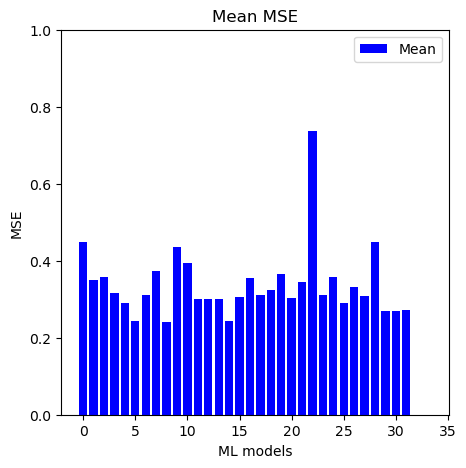

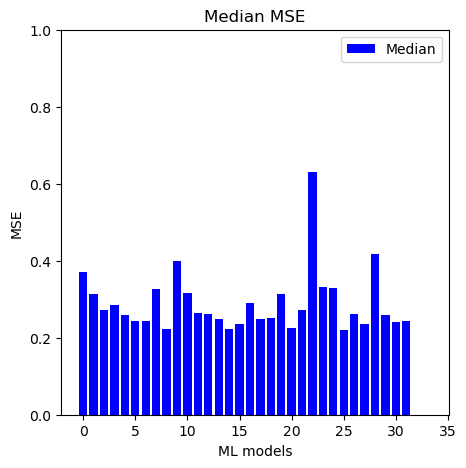

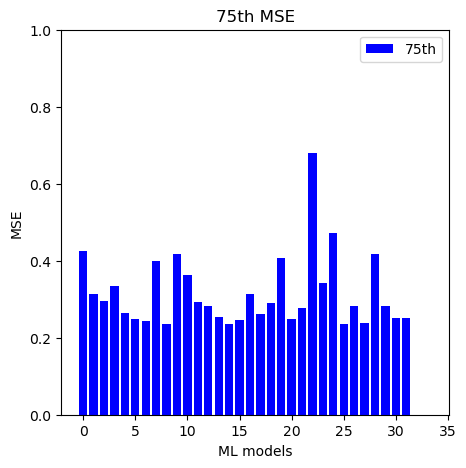

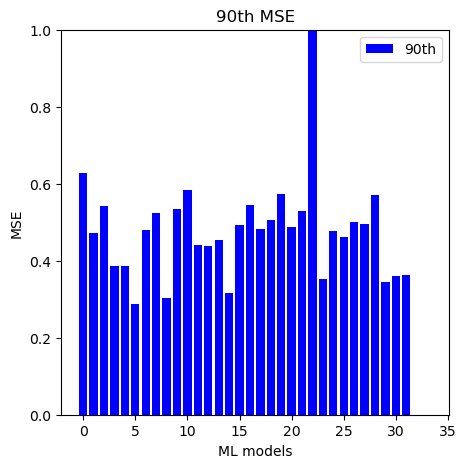

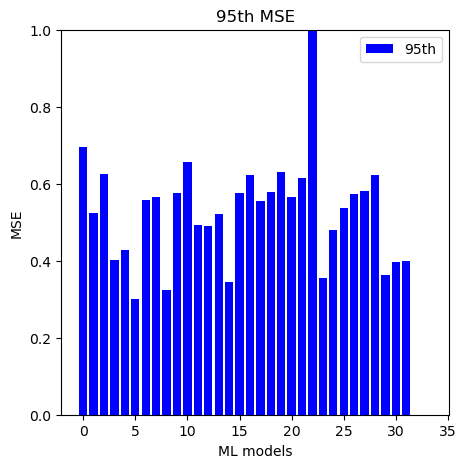

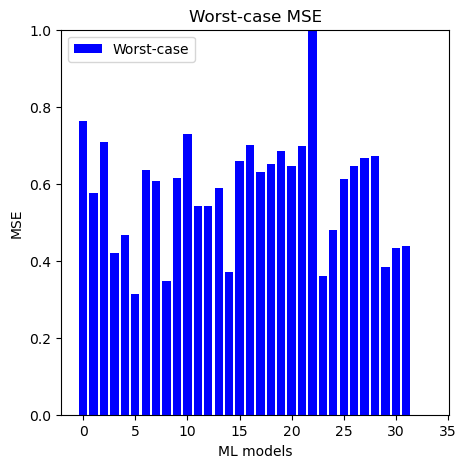

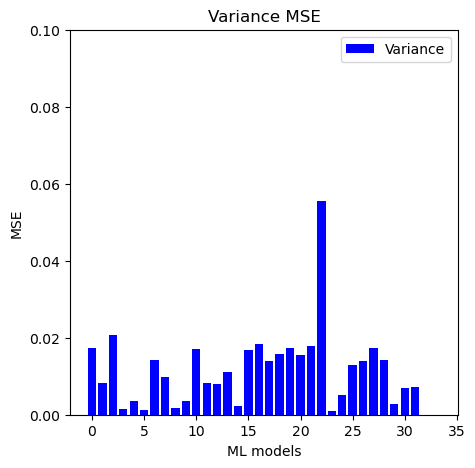

In [24]:
# display the statistica as bar plot

#plot the mean
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['mean'])), stats_mse_estimates['mean'], color='blue', label='Mean')
plt.title('Mean MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show() 

#plot the median
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['median'])), stats_mse_estimates['median'], color='blue', label='Median')
plt.title('Median MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show() 

#plot the 75th
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['75th'])), stats_mse_estimates['75th'], color='blue', label='75th')
plt.title('75th MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()

#plot the 90th
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['90th'])), stats_mse_estimates['90th'], color='blue', label='90th')
plt.title('90th MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()

#plot the 95th
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['95th'])), stats_mse_estimates['95th'], color='blue', label='95th')
plt.title('95th MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()

# plot the worst-case
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['worst-case'])), stats_mse_estimates['worst-case'], color='blue', label='Worst-case')
plt.title('Worst-case MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()


# plot the variance
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['variance'])), stats_mse_estimates['variance'], color='blue', label='Variance')
plt.title('Variance MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0,0.1)
plt.legend()
plt.show()

# Idea: Test by combining the predictions of different denoising models

In [25]:
# Test the M denoising models and weighted predictions

w_ridge_per_model = {}
w_ridge_low_rank_per_model = {}

rmse_per_model = {}
rmse_low_rank_per_model = {}

lambda_tmp = 2500.0


for dir in list(dic_data_yearly.keys()):
    print(f'Computing ridge regression for {dir}')

    # merge the corrupted data  and the original data for this specific model 
    x_train_yearly_tmp = torch.from_numpy(dic_data_yearly[dir]).to(torch.float32).reshape(dic_data_yearly[dir].shape[0]*dic_data_yearly[dir].shape[1],dic_data_yearly[dir].shape[2]*dic_data_yearly[dir].shape[3])    
    y_train_yearly_tmp = torch.from_numpy(dic_forced_response_yearly[dir]).to(torch.float32).reshape(dic_forced_response_yearly[dir].shape[0]*dic_forced_response_yearly[dir].shape[1],dic_forced_response_yearly[dir].shape[2]*dic_forced_response_yearly[dir].shape[3])

    w_ridge_per_model[dir] = ridge_regression(x_train_yearly_tmp, y_train_yearly_tmp, lambda_reg= lambda_tmp, verbose=True)

    # low rank regression
    U,S,V = torch.linalg.svd(x_train_yearly_tmp@w_ridge_per_model[dir],full_matrices=False)

    # # define the rank
    rank = 30

    w_ridge_low_rank_per_model[dir] = w_ridge_per_model[dir] @ V[:rank,:].T@V[:rank,:]

    # Evaluate the model on test data
    y_pred_tmp = torch.from_numpy(x_test) @ w_ridge_per_model[dir]
    y_pred_low_rank_tmp= torch.from_numpy(x_test) @ w_ridge_low_rank_per_model[dir]

    # Average the predictions yearly
    y_pred_tmp = y_pred_tmp.reshape(y_pred_tmp.shape[0], y_pred_tmp.shape[1] // 12, 12, y_pred_tmp.shape[2])
    y_pred_tmp = y_pred_tmp.mean(axis=2)

    y_pred_low_rank_tmp = y_pred_low_rank_tmp.reshape(y_pred_low_rank_tmp.shape[0], y_pred_low_rank_tmp.shape[1] // 12, 12, y_pred_low_rank_tmp.shape[2])
    y_pred_low_rank_tmp = y_pred_low_rank_tmp.mean(axis=2)

    # Compute the mean squared error
    rmse_per_model[dir] = torch.sqrt(torch.mean((y_pred_tmp - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()
    rmse_low_rank_per_model[dir] = torch.sqrt(torch.mean((y_pred_low_rank_tmp - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()


    print(f'  MSE : {rmse_per_model[dir]}')
    print(f'  MSE trace norm: {rmse_low_rank_per_model[dir]}')

Computing ridge regression for CESM2
Solving ridge regression with λ=2500.0
Input shape: X=torch.Size([11050, 10368]), Y=torch.Size([11050, 10368])
Reshaped: X=torch.Size([11050, 10368]), Y=torch.Size([11050, 10368])
Ridge weights computed: torch.Size([10368, 10368])


  MSE : [0.23011388 0.2563901  0.2671294  0.3086721  0.23925847]
  MSE trace norm: [0.23032516 0.25714    0.26751715 0.30901375 0.23990957]
Computing ridge regression for CanESM5
Solving ridge regression with λ=2500.0
Input shape: X=torch.Size([5525, 10368]), Y=torch.Size([5525, 10368])
Reshaped: X=torch.Size([5525, 10368]), Y=torch.Size([5525, 10368])
Ridge weights computed: torch.Size([10368, 10368])
  MSE : [0.22003011 0.5156991  0.23268482 0.2520663  0.25286487]
  MSE trace norm: [0.21993792 0.51632065 0.233541   0.25244415 0.2539818 ]
Computing ridge regression for MIROC-ES2L
Solving ridge regression with λ=2500.0
Input shape: X=torch.Size([6630, 10368]), Y=torch.Size([6630, 10368])
Reshaped: X=torch.Size([6630, 10368]), Y=torch.Size([6630, 10368])
Ridge weights computed: torch.Size([10368, 10368])
  MSE : [0.22149907 0.4104285  0.21912833 0.23689528 0.26560172]
  MSE trace norm: [0.22176762 0.4114387  0.2198553  0.2373257  0.26674533]
Computing ridge regression for MIROC6
Solving

In [26]:
# Given the M denoising models, one can compute a convex combination of the predictions 
# based on the distance to the training data of the climate model m.

def distance_to_training_data(x, x_train):
    """
    Compute the distance of the predictions to the training data.
    
    Args:
        x: torch.Tensor of shape (n_samples, n_timesteps, n_features)
        y: torch.Tensor of shape (n_samples, n_timesteps, n_features)
    
    Returns:
        distances: torch.Tensor of shape (n_samples,)
    """
    distances = torch.zeros((x.shape[0]), dtype=torch.float32)
    for i in range(x.shape[0]):
        distances[i] = torch.mean(torch.sqrt(torch.sum((x[i,:,:] - x_train[:,years_test_idx_feature,:]) ** 2, dim=(1, 2))),axis=0)
    print(f'  distances shape: {distances.shape}')
    return distances

def compute_weights(x,x_train):
    """
    Compute weights based on distances to training data.
    
    Args:
        distances: torch.Tensor of shape (n_samples,)
    
    Returns:
        weights: torch.Tensor of shape (n_samples,)
    """
    distances = {}
    weights = torch.zeros((x.shape[0],len(x_train.keys())) , dtype=torch.float32)    
 
    for idx_m, m in enumerate(list(x_train.keys())):
        distances[m] = distance_to_training_data(x,x_train[m])
        print(f'  distances for model {m} shape: {distances[m].shape}')
        weights[:,idx_m] = 1.0 / (distances[m] + 1e-8)  # Add small value to avoid division by zero

    # Normalize weights across all models
    weights = weights / torch.sum(weights, dim=0, keepdim=True)

    return weights

In [27]:
# Given the M denoising models, one can compute a convex combination of the predictions 
# based on the distance to the training data of the climate model m.

def training_losses(x, y, w):
    """
    Compute the distance of the predictions to the training data.
    
    Args:
        x: torch.Tensor of shape (n_samples, n_timesteps, n_features)
        y: torch.Tensor of shape (n_samples, n_timesteps, n_features)
        w: torch.Tensor of shape (n_features, n_outputs)
    
    Returns:
        distances: torch.Tensor of shape (n_samples,)
    """
    y_pred = x @ w
    distances = torch.sqrt(torch.mean((y_pred - y) ** 2, dim=(1, 2)))
    return distances

def compute_weights_training_losses(w,x,y):
    """
    Compute weights based on distances to training data.
    
    Args:
        distances: torch.Tensor of shape (n_samples,)
    
    Returns:
        weights: torch.Tensor of shape (n_samples,)
    """
    distances = {}
    weights = torch.zeros((len(w.keys())), dtype=torch.float32)    
 
    for idx_m, m in enumerate(list(w.keys())):
        distances[m] = torch.mean(training_losses(x[m],y[m],w[m]))
        weights[idx_m] = 1.0 / (distances[m] + 1e-8)  # Add small value to avoid division by zero

    # Normalize weights across all models
    weights = weights / torch.sum(weights, dim=0, keepdim=True)

    return weights

# Yearly predictions using average predictions.

In [28]:
# compute training score for each climate model
training_scores = torch.zeros((len(dic_data_yearly.keys())), dtype=torch.float32)
training_scores_low_rank = torch.zeros((len(dic_data_yearly.keys())), dtype=torch.float32)

for idx_m, m in enumerate(dic_data_yearly.keys()):
    print(f'Computing training score for model {m}')
    training_scores[idx_m] = torch.mean(training_losses(x_yearly[m], y_yearly[m], w_ridge_per_model[m]))
    training_scores_low_rank[idx_m] = torch.mean(training_losses(x_yearly[m], y_yearly[m], w_ridge_low_rank_per_model[m]))
    print(f'  Training score shape: {training_scores[idx_m].shape}')

Computing training score for model CESM2
  Training score shape: torch.Size([])
Computing training score for model CanESM5
  Training score shape: torch.Size([])
Computing training score for model MIROC-ES2L
  Training score shape: torch.Size([])
Computing training score for model MIROC6
  Training score shape: torch.Size([])
Computing training score for model MPI-ESM1-2-LR
  Training score shape: torch.Size([])


In [29]:
weights = 1/len(w_ridge_per_model.keys()) * torch.ones((len(w_ridge_per_model.keys()),), dtype=torch.float32)
weights_lr = 1/len(w_ridge_low_rank_per_model.keys()) * torch.ones((len(w_ridge_low_rank_per_model.keys()),), dtype=torch.float32)

# weights = training_scores / torch.sum(training_scores, dim=0, keepdim=True)
# weights_lr = training_scores_low_rank / torch.sum(training_scores_low_rank, dim=0, keepdim=True)


x_test_torch = torch.from_numpy(x_test).to(torch.float32)
x_test_ma = moving_average_smoothing(x_test_torch, window_size=25, mode='same')

y_pred_weighted = torch.zeros_like(x_test_torch)
y_pred_low_rank_weighted = torch.zeros_like(x_test_torch)

for idx_m, m in enumerate(dic_data_yearly.keys()):
    print(f'Processing model: {m}')
    for i in range(x_test_torch.shape[0]):
        y_pred_weighted[i, :, :] += weights[idx_m] * (x_test_torch[i,:, :] @ w_ridge_per_model[m])
        y_pred_low_rank_weighted[i, :, :] += weights[idx_m] * (x_test_torch[i,:,:] @ w_ridge_low_rank_per_model[m])

# compute yearly average of the predictions
y_pred_weighted = y_pred_weighted.reshape(y_pred_weighted.shape[0], y_pred_weighted.shape[1] // 12, 12, y_pred_weighted.shape[2])
y_pred_weighted = y_pred_weighted.mean(axis=2) 

y_pred_low_rank_weighted = y_pred_low_rank_weighted.reshape(y_pred_low_rank_weighted.shape[0], y_pred_low_rank_weighted.shape[1] // 12, 12, y_pred_low_rank_weighted.shape[2])
y_pred_low_rank_weighted = y_pred_low_rank_weighted.mean(axis=2)    

# Compute the mean squared error
rmse_weighted_yearly = torch.sqrt(torch.mean((y_pred_weighted - y_test_yearly) ** 2, axis=(1, 2))).detach().numpy()
rmse_weighted_low_rank_yearly = torch.sqrt(torch.mean((y_pred_low_rank_weighted - y_test_yearly) ** 2, axis=(1, 2))).detach().numpy()


print(f'  MSE Ridge Regression: {rmse}')
print(f'  MSE Low Rank Ridge Regression: {rmse_low_rank}')
print(f'  MSE weighted prediction: {rmse_weighted_yearly}')
print(f'  MSE weighted prediction trace norm: {rmse_weighted_low_rank_yearly}')

Processing model: CESM2
Processing model: CanESM5
Processing model: MIROC-ES2L
Processing model: MIROC6
Processing model: MPI-ESM1-2-LR
  MSE Ridge Regression: [0.2082471  0.43262067 0.20838577 0.25053516 0.24116245]
  MSE Low Rank Ridge Regression: [0.20933408 0.43757844 0.2136881  0.25190958 0.24283701]
  MSE weighted prediction: [0.18233185 0.31496665 0.20485273 0.22789665 0.23457927]
  MSE weighted prediction trace norm: [0.18242347 0.3158007  0.20569685 0.22827987 0.2356132 ]


In [30]:
stats_mse_estimates['mean'][data_estimates.shape[0]+2] = np.mean(rmse_weighted_yearly, axis=0)
stats_mse_estimates['median'][data_estimates.shape[0]+2] = np.median(rmse_weighted_yearly, axis=0)
stats_mse_estimates['75th'][data_estimates.shape[0]+2] = np.quantile(rmse_weighted_yearly, 0.75, axis=0)
stats_mse_estimates['90th'][data_estimates.shape[0]+2] = np.quantile(rmse_weighted_yearly, 0.90, axis=0)
stats_mse_estimates['95th'][data_estimates.shape[0]+2] = np.quantile(rmse_weighted_yearly, 0.95, axis=0)
stats_mse_estimates['worst-case'][data_estimates.shape[0]+2] = np.max(rmse_weighted_yearly, axis=0)
stats_mse_estimates['variance'][data_estimates.shape[0]+2] = np.var(rmse_weighted_yearly, axis=0)

stats_mse_estimates['mean'][data_estimates.shape[0]+3] = np.mean(rmse_weighted_low_rank_yearly, axis=0)
stats_mse_estimates['median'][data_estimates.shape[0]+3] = np.median(rmse_weighted_low_rank_yearly, axis=0)
stats_mse_estimates['75th'][data_estimates.shape[0]+3] = np.quantile(rmse_weighted_low_rank_yearly, 0.75, axis=0)
stats_mse_estimates['90th'][data_estimates.shape[0]+3] = np.quantile(rmse_weighted_low_rank_yearly, 0.90, axis=0)
stats_mse_estimates['95th'][data_estimates.shape[0]+3] = np.quantile(rmse_weighted_low_rank_yearly, 0.95, axis=0)
stats_mse_estimates['worst-case'][data_estimates.shape[0]+3] = np.max(rmse_weighted_low_rank_yearly, axis=0)
stats_mse_estimates['variance'][data_estimates.shape[0]+3] = np.var(rmse_weighted_low_rank_yearly, axis=0)

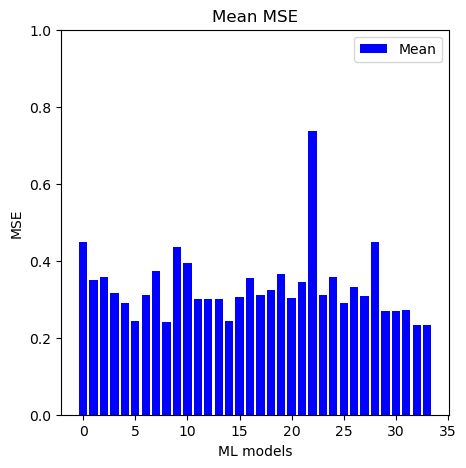

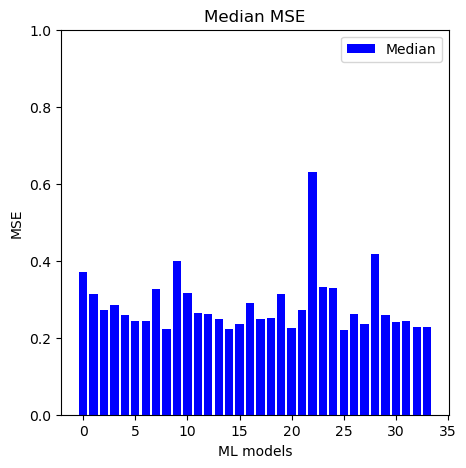

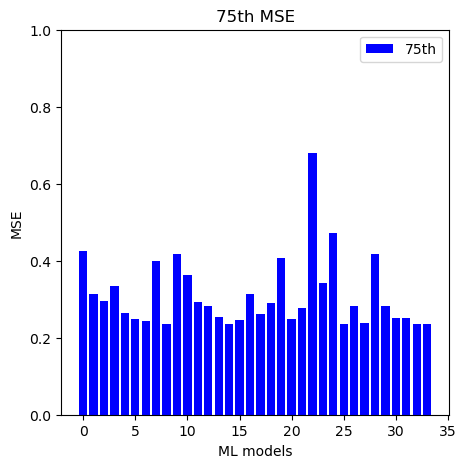

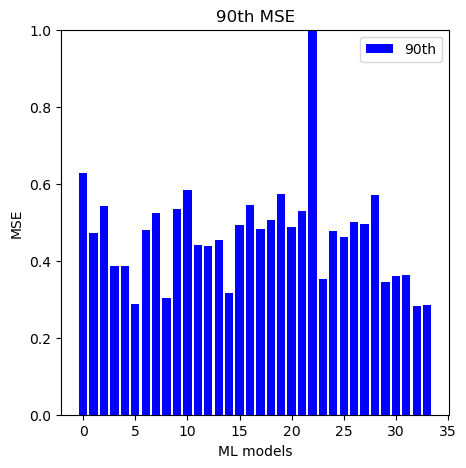

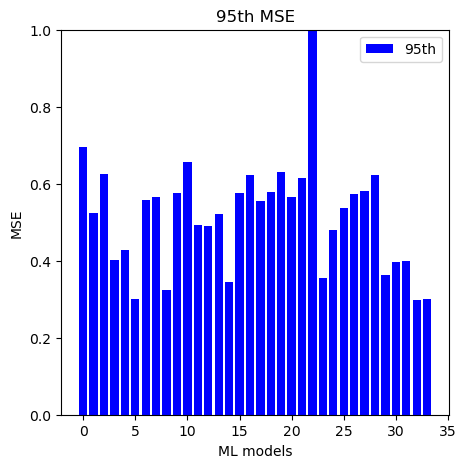

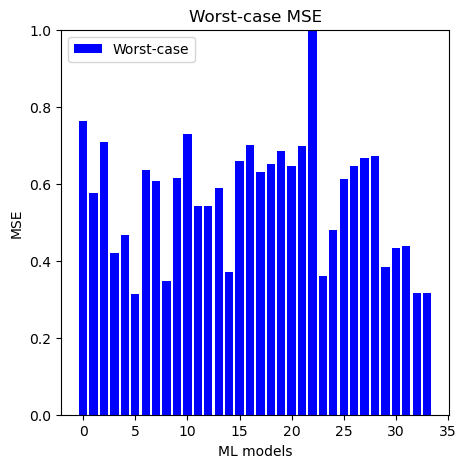

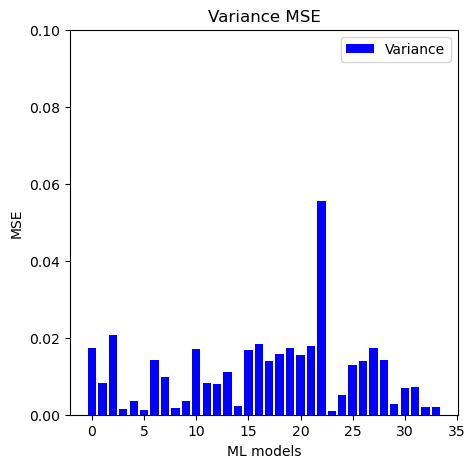

In [31]:
# display the statistica as bar plot

#plot the mean
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['mean'])), stats_mse_estimates['mean'], color='blue', label='Mean')
plt.title('Mean MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show() 

#plot the median
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['median'])), stats_mse_estimates['median'], color='blue', label='Median')
plt.title('Median MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show() 

#plot the 75th
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['75th'])), stats_mse_estimates['75th'], color='blue', label='75th')
plt.title('75th MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()

#plot the 90th
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['90th'])), stats_mse_estimates['90th'], color='blue', label='90th')
plt.title('90th MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()

#plot the 95th
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['95th'])), stats_mse_estimates['95th'], color='blue', label='95th')
plt.title('95th MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()

# plot the worst-case
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['worst-case'])), stats_mse_estimates['worst-case'], color='blue', label='Worst-case')
plt.title('Worst-case MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()


# plot the variance
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['variance'])), stats_mse_estimates['variance'], color='blue', label='Variance')
plt.title('Variance MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0,0.1)
plt.legend()
plt.show()

# Idea of Sebastien: Train a classifier that will give a score to each new ensemble member

In [32]:
# def stack_models_and_runs(models,x,y, dtype=torch.float32):
#     """Stack all ensemble members of all models in a single tensor.

#        Args:

#        Return:
#     """

#     for idx_m,m in enumerate(models):
#         if idx_m == 0:
#             x_stacked = torch.from_numpy(x[m]).view(x[m].shape[0],x[m].shape[1],-1)
#             y_stacked = torch.from_numpy(y[m]).view(y[m].shape[0],y[m].shape[1],-1)
#         else:   
#             x_stacked = torch.cat((x_stacked, torch.from_numpy(x[m]).view(x[m].shape[0],x[m].shape[1],-1)), dim=0)
#             y_stacked = torch.cat((y_stacked, torch.from_numpy(y[m]).view(y[m].shape[0],y[m].shape[1],-1)), dim=0)

#     return x_stacked, y_stacked

In [33]:
# models = list(dic_data.keys())

# time_length = len(years_test_idx_feature)

# # build the dataset for training the classifier
# x_stacked, y_stacked = stack_models_and_runs(models,dic_data_yearly, dic_forced_response_yearly)   
# x_stacked = x_stacked.reshape(x_stacked.shape[0], x_stacked.shape[1], -1)  # reshape to (n_samples, time_length, n_features)
# y_stacked = y_stacked.reshape(y_stacked.shape[0], y_stacked.shape[1], -1)  # reshape to (n_samples, time_length, n_features)

# # define labels for each sample
# labels = np.zeros((x_stacked.shape[0]*time_length), dtype=np.int64)
# last_idx = 0

# # Assign labels based on the model index
# for idx_m, m in enumerate(list(dic_data_yearly.keys())):
#     # Get the indices for the current model

#     labels[last_idx:last_idx+dic_data_yearly[m].shape[0]*time_length] = idx_m
#     last_idx = last_idx+dic_data_yearly[m].shape[0]*time_length


# x_train_classifier = np.zeros((x_stacked.shape[0]*time_length, x_stacked.shape[2]), dtype=np.float32)
# last_idx = 0
# for idx_m, m in enumerate(list(dic_data_yearly.keys())):
#     print(f'Processing model {m} with shape {dic_data_yearly[m].shape}')
#     # print(x_train_classifier[last_idx:last_idx+dic_data_yearly[m].shape[0]*time_length,:].shape)
#     # print(x_stacked[last_idx:last_idx+dic_data_yearly[m].shape[0],years_test_idx_feature,:])
#     # print(dic_data_yearly[m][:,years_test_idx_feature,:].reshape(-1,dic_data_yearly[m].shape[2]*dic_data_yearly[m].shape[3]).shape)
#     x_train_classifier[last_idx:last_idx+dic_data_yearly[m].shape[0]*time_length,:] = dic_data_yearly[m][:,years_test_idx_feature,:].reshape(-1,dic_data_yearly[m].shape[2]*dic_data_yearly[m].shape[3]).reshape(dic_data_yearly[m].shape[0]*time_length, -1)
#     last_idx = last_idx + dic_data_yearly[m].shape[0]*time_length

In [34]:
# # train logistic regression classifier
# from sklearn.linear_model import LogisticRegression

# classifier = LogisticRegression(C=1000, penalty='l2')
# classifier.fit(x_train_classifier, labels)

In [35]:
# # compute probabilities of the test data
# predicted_labels = classifier.predict(x_test_yearly.reshape(x_test_yearly.shape[0]*x_test_yearly.shape[1], -1 ))  # reshape to (n_samples, n_features)
# predicted_proba = classifier.predict_proba(x_test_yearly.reshape(x_test_yearly.shape[0]*x_test_yearly.shape[1], -1 ))    
# predicted_proba = predicted_proba.reshape(x_test_yearly.shape[0], x_test_yearly.shape[1], -1)  # reshape to (n_samples, time_length, n_classes)

In [36]:
# # get the training error
# train_error = 1 - classifier.score(x_train_classifier, labels)
# print(f'Training error: {train_error}')

In [37]:
# plot the probabilities for the first sample as time series
# import matplotlib.pyplot as plt
# plt.figure(figsize=(10, 5))
# for idx_m in range(predicted_proba.shape[2]):
#     plt.plot(predicted_proba[0, :, idx_m], label=f'Model {idx_m}')
# plt.title('Predicted Probabilities for Each Model')
# plt.xlabel('Time')
# plt.ylabel('Probability')
# plt.legend()
# plt.show()  

In [38]:
# x_test_yearly_torch = torch.from_numpy(x_test_yearly).to(torch.float32)
# y_test_yearly_torch = torch.from_numpy(y_test_yearly).to(torch.float32)

In [39]:
# weights = torch.from_numpy(predicted_proba).to(torch.float32) # Average probabilities over time
# weights_lr = torch.from_numpy(predicted_proba).to(torch.float32)

# # assign binary weights = 1 with labels coresponding to the model


# # weighted predictions
# y_pred = x_test_yearly_torch @ w_ridge
# y_pred_low_rank = x_test_yearly_torch@ w_ridge_low_rank

# y_pred_weighted = torch.zeros_like(x_test_yearly_torch)
# y_pred_low_rank_weighted = torch.zeros_like(x_test_yearly_torch)

# for idx_m, m in enumerate(dic_data_yearly.keys()):
#     print(f'Processing model: {m}')
#     for i in range(x_test_yearly.shape[0]):
#         print(f'  Sample {i+1}/{x_test_yearly_torch.shape[0]}')
#         print((x_test_yearly_torch[i,:, :] @ w_ridge_per_model[m]).shape)
#         y_pred_weighted[i, :, :] += weights[i,:,idx_m ] @ (x_test_yearly_torch[i,:, :] @ w_ridge_per_model[m])
#         y_pred_low_rank_weighted[i, :, :] += weights[i,:,idx_m ] @ (x_test_yearly_torch[i,:,:] @ w_ridge_low_rank_per_model[m])

# # compute the mse between the prediction and the ground truth
# rmse_weighted = torch.sqrt(torch.mean((y_pred_weighted - y_test_yearly_torch) ** 2,axis=(1,2))).detach().numpy()
# rmse_low_rank_weight =  torch.sqrt(torch.mean((y_pred_low_rank_weighted - y_test_yearly_torch) ** 2,axis=(1,2))).detach().numpy()


# print(f'RMSE Ridge Regression: {rmse}')
# print(f'RMSE Low Rank Ridge Regression: {rmse_low_rank}')
# print(f'RMSE Weighted Ridge Regression: {rmse_weighted}')
# print(f'RMSE Weighted Low Rank Ridge Regression: {rmse_low_rank_weight}')

# Metrics of the ForceSMIP challenge

### metric to evaluate the methods
### - long term trends: 1. uncetered pattern correlation: $r_i = \langle f_i, f_0 \rangle \lVert f_i \rVert^{-1}  \lVert f_0 \rVert^{-1}$ where $\lVert \cdot \rVert = p^{-1} \sqrt{\langle \cdot, \cdot \rangle}$ and $p$ is the total number of grid cells.
### - $RMSE = \lVert f_i - f_0 \rVert$ normalized by the amplitude of the forced response $\lVert f_0 \rVert$.
### -  amplitude ratio of the predicted and the true forced response pattern $\gamma_i = \frac{\lVert f_i \rVert}{\lVert f_0 \rVert}$

## It  turns out that $r_i = \frac{1+ \gamma_i^2 - \mathrm{nRMSE}_i^2}{2 \gamma_i}$

### 1. Compute normalized RMSE for each ensemble member in the test set

In [40]:
### Training dates 
years_train = np.arange(2100 - 1880 +1)

# year index to a scalar in [0,1]
years_train_idx_feature = years_train   # normalize to [0,1] range

# get index of years 1950 - 2022
years_test = years_train[(years_train >= 1950-1880) & (years_train <= 2022-1880)]

# do the computation for the test years 1980 - 2022
years_test_idx_feature =  years_test[30:]

# print("Training years:", years_train_idx_feature)
x_test_yearly_torch_tmp = torch.from_numpy(x_test_yearly)[:, 30:, :]
y_test_yearly_torch_tmp = torch.from_numpy(y_test_yearly)[:, 30:, :]

# compute yearly average of the predictions
y_pred_tmp = y_pred_yearly[:, 30:, :]
y_pred_low_rank_tmp = y_pred_lr_yearly[:, 30:, :]
y_pred_weighted_tmp = y_pred_weighted[:,30:,:]
y_pred_low_rank_weighted_tmp = y_pred_low_rank_weighted[:,30:,:]

data_estimates_yearly_torch = torch.from_numpy(data_estimates_yearly).to(torch.float32).reshape(data_estimates_yearly.shape[0], data_estimates_yearly.shape[1], data_estimates_yearly.shape[2],-1)  # reshape to (n_samples, time_length, n_features)
data_estimates_yearly_tmp = data_estimates_yearly_torch[:, :, 30:, :]

In [41]:
# compute the trend of y_pred
trend_pred = np.zeros((y_pred_tmp.shape[0], y_pred_tmp.shape[2]), dtype=np.float32)
for i in range(y_pred_tmp.shape[0]):
    trend_pred[i, :] = np.polyfit(np.arange(y_pred_tmp.shape[1]), y_pred_tmp[i, :, :], 1)[0]


# compute the trend of y_pred_weighted
trend_pred_weighted = np.zeros((y_pred_weighted_tmp.shape[0], y_pred_weighted_tmp.shape[2]), dtype=np.float32)
for i in range(y_pred_weighted_tmp.shape[0]):
    trend_pred_weighted[i, :] = np.polyfit(np.arange(y_pred_weighted_tmp.shape[1]), y_pred_weighted_tmp[i, :, :], 1)[0]

# compute the trend of y_pred_low_rank
trend_pred_weighted_low_rank = np.zeros((y_pred_low_rank_weighted_tmp.shape[0], y_pred_low_rank_weighted_tmp.shape[2]), dtype=np.float32)
for i in range(y_pred_low_rank_weighted_tmp.shape[0]):
    trend_pred_weighted_low_rank[i, :] = np.polyfit(np.arange(y_pred_low_rank_weighted_tmp.shape[1]), y_pred_low_rank_weighted_tmp[i, :, :], 1)[0]


# compute the trend of each estimates
trend_estimates = np.zeros((data_estimates_yearly_tmp.shape[0], data_estimates_yearly_tmp.shape[1], data_estimates_yearly_tmp.shape[3]), dtype=np.float32)
for i in range(data_estimates_yearly_tmp.shape[0]):
    for j in range(data_estimates_yearly_tmp.shape[1]):
        # Fit a linear trend to the data estimates for each model and each year
        # data_estimates_yearly[i, j, :] is the data estimates for model i and year j
        # np.polyfit returns the coefficients of the polynomial fit, we take the first coefficient (the slope)
        trend_estimates[i, j, :] = np.polyfit(np.arange(data_estimates_yearly_tmp.shape[2]), data_estimates_yearly_tmp[i, j, :, :], 1)[0]

In [42]:
# compute the trend of the target forced response
trend_forced_response = np.zeros((y_test_yearly_torch_tmp.shape[0], y_test_yearly_torch_tmp.shape[2]), dtype=np.float32)
for i in range(y_test_yearly_torch_tmp.shape[0]):
    # Fit a linear trend to the data estimates for each model and each year
    # y_test_yearly_torch_tmp[i, j, :] is the target forced response for model i and year j
    # np.polyfit returns the coefficients of the polynomial fit, we take the first coefficient (the slope)
    trend_forced_response[i, :] = np.polyfit(np.arange(y_test_yearly_torch_tmp.shape[1]), y_test_yearly_torch_tmp[i, :, :], 1)[0]

In [43]:
# 1. Compute normalized RMSE for each ensemble member in the test set
normalized_rmse = np.zeros((trend_pred.shape[0]) , dtype=np.float32)
normalized_rmse = np.linalg.norm((trend_pred - trend_forced_response), axis=1) / np.linalg.norm(trend_forced_response, axis=1)

normalized_rmse_weighted = np.zeros((trend_pred_weighted.shape[0]) , dtype=np.float32)
normalized_rmse_weighted = np.linalg.norm((trend_pred_weighted - trend_forced_response), axis=1) / np.linalg.norm(trend_forced_response, axis=1)

# compute the normalized MSE for all the methods
normalized_rmse_weighted_low_rank = np.zeros((trend_pred_weighted_low_rank.shape[0],) , dtype=np.float32)
normalized_rmse_weighted_low_rank = np.linalg.norm((trend_pred_weighted_low_rank - trend_forced_response), axis=1) / np.linalg.norm(trend_forced_response, axis=1)

In [44]:
# compute the yearly mse of the other estimates 
# compute mse of the other estimates
normalized_rmse_estimates = np.zeros((trend_estimates.shape[0],trend_estimates.shape[1]) , dtype=np.float32)

for idx_r in range(trend_estimates.shape[0]):
    normalized_rmse_estimates[idx_r,:] = np.linalg.norm((trend_estimates[idx_r,:,:] - trend_forced_response), axis=1) / np.linalg.norm(trend_forced_response, axis=1)
    print(f'  MSE estimates: {normalized_rmse_estimates[idx_r,:]}')

  MSE estimates: [0.3013218  0.7144838  0.16420142 0.32694486 0.48609385]
  MSE estimates: [0.2637627  0.5384785  0.22678645 0.307623   0.4650934 ]
  MSE estimates: [0.29365444 0.67756253 0.15188314 0.3308041  0.4947739 ]
  MSE estimates: [0.27264193 0.33972993 0.39719194 0.26346266 0.448021  ]
  MSE estimates: [0.31511495 0.52229357 0.22749181 0.23833564 0.37792656]
  MSE estimates: [0.24417101 0.31166437 0.32486343 0.33048448 0.4497944 ]
  MSE estimates: [0.27985466 0.8066365  0.19866985 0.29124212 0.44317207]
  MSE estimates: [0.37988305 0.5894946  0.30942908 0.38719988 0.7486792 ]
  MSE estimates: [0.26912752 0.3669702  0.23095524 0.24230553 0.3692168 ]
  MSE estimates: [0.2141976  0.47931656 0.21589659 0.31439522 0.41927493]
  MSE estimates: [0.29753077 0.65971285 0.16059464 0.33395556 0.4944599 ]
  MSE estimates: [0.33428112 0.7442771  0.14485921 0.31022286 0.42964035]
  MSE estimates: [0.30390358 0.6952597  0.14595194 0.26576555 0.4200764 ]
  MSE estimates: [0.2641756  0.8470918

### 2. compute the amplitude ratio

In [45]:
amplitude_ratio = np.linalg.norm(trend_pred, axis=1) / np.linalg.norm(trend_forced_response, axis=1)
amplitude_ratio_weighted = np.linalg.norm(trend_pred_weighted, axis=1) / np.linalg.norm(trend_forced_response, axis=1)
amplitude_ratio_weighted_low_rank = np.linalg.norm(trend_pred_weighted_low_rank, axis=1) / np.linalg.norm(trend_forced_response, axis=1)

# compute the amplitude ratio for the other estimates
amplitude_ratio_estimates = np.zeros((trend_estimates.shape[0],trend_estimates.shape[1]) , dtype=np.float32)
for i in range(trend_estimates.shape[0]):
    amplitude_ratio_estimates[i,:] = np.linalg.norm(trend_estimates[i,:,:], axis=1) / np.linalg.norm(trend_forced_response, axis=1)

### 3. Compute the pattern correlation

In [46]:
pattern_corr = (1 + amplitude_ratio**2 - normalized_rmse**2) / (2 * amplitude_ratio)
pattern_corr_weighted = (1 + amplitude_ratio_weighted**2 - normalized_rmse_weighted**2) / (2 * amplitude_ratio_weighted)
pattern_corr_weighted_low_rank = (1 + amplitude_ratio_weighted_low_rank**2 - normalized_rmse_weighted_low_rank**2) / (2 * amplitude_ratio_weighted_low_rank)

pattern_corr_estimates = np.zeros((trend_estimates.shape[0],trend_estimates.shape[1]) , dtype=np.float32)
for i in range(trend_estimates.shape[0]):
    pattern_corr_estimates[i] = (1 + amplitude_ratio_estimates[i,:]**2 - normalized_rmse_estimates[i,:]**2) / (2 * amplitude_ratio_estimates[i,:])

### 4. Display the results for each quantity

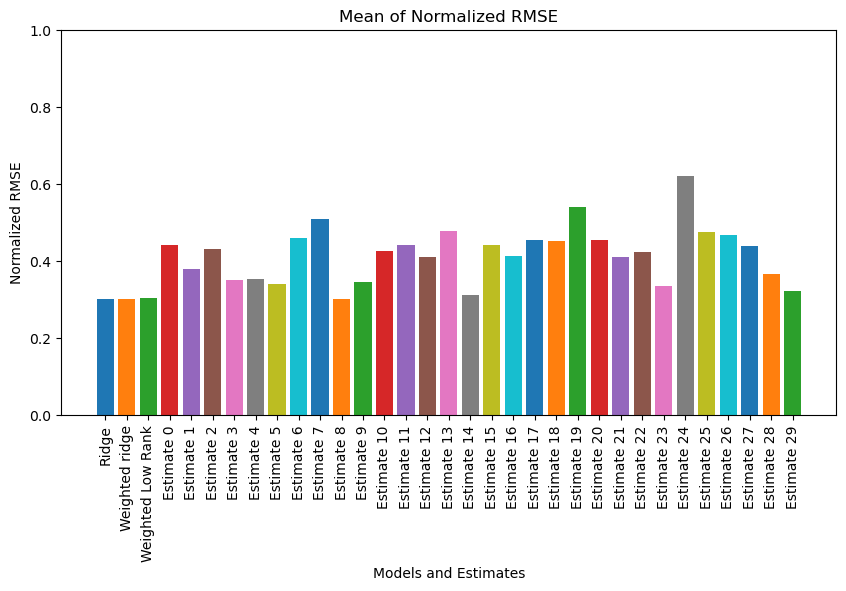

In [47]:
# display the statistics as bar plot
nrmse = {
    'Ridge': normalized_rmse,
    'Weighted ridge': normalized_rmse_weighted,
    'Weighted Low Rank': normalized_rmse_weighted_low_rank
}
for i in range(normalized_rmse_estimates.shape[0]):
    nrmse[f'Estimate {i}'] = normalized_rmse_estimates[i,:]

# Plotting the mean normalized RMSE
plt.figure(figsize=(10, 5))
for label, values in nrmse.items():
    plt.bar(label, np.sqrt(np.mean(values**2)), label=label)
plt.title('Mean of Normalized RMSE')
plt.xlabel('Models and Estimates')
plt.ylabel('Normalized RMSE')
plt.ylim(0, 1)
plt.xticks(rotation=90)
# plt.legend()
plt.show()


# # Plotting the 95th percentile normalized RMSE
# plt.figure(figsize=(10, 5))
# for label, values in nrmse.items():
#     plt.bar(label, np.quantile(values,0.9), label=label)
# plt.title('90th Percentile of Normalized RMSE')
# plt.xlabel('Models and Estimates')
# plt.ylabel('Normalized RMSE')
# plt.ylim(0, 1)
# plt.xticks(rotation=90)
# # plt.legend()
# plt.show()

# # Plotting the worst case normalized RMSE
# plt.figure(figsize=(10, 5))
# for label, values in nrmse.items():
#     plt.bar(label, np.max(values), label=label)
# plt.title('Worst Case Normalized RMSE')
# plt.xlabel('Models and Estimates')
# plt.ylabel('Normalized RMSE')
# plt.ylim(0, 1)
# plt.xticks(rotation=90)
# # plt.legend()
# plt.show()  

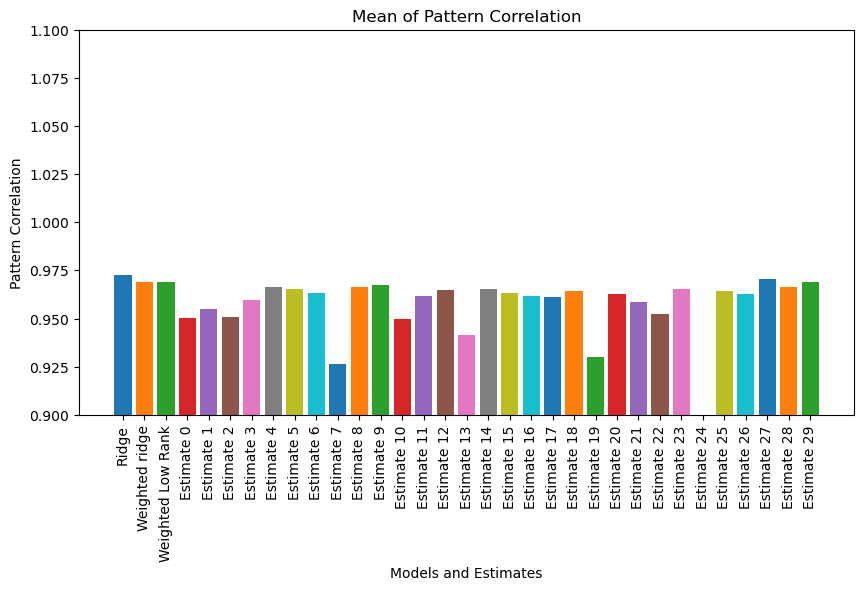

In [48]:
# plotting the pattern correlation
pattern = {
    'Ridge': pattern_corr,
    'Weighted ridge': pattern_corr_weighted,
    'Weighted Low Rank': pattern_corr_weighted_low_rank
} 
for i in range(pattern_corr_estimates.shape[0]):
    pattern[f'Estimate {i}'] = pattern_corr_estimates[i,:]


# Plotting the mean pattern correlation
plt.figure(figsize=(10, 5))
for label, values in pattern.items():
    plt.bar(label, np.sqrt(np.mean(values**2)), label=label)
plt.title('Mean of Pattern Correlation')
plt.xlabel('Models and Estimates')
plt.ylabel('Pattern Correlation')
plt.ylim(0.9, 1.1)
plt.xticks(rotation=90)
# plt.legend()
plt.show()

# Display the map

Displaying triple comparison (Ground Truth vs Ridge Prediction vs Test Member):


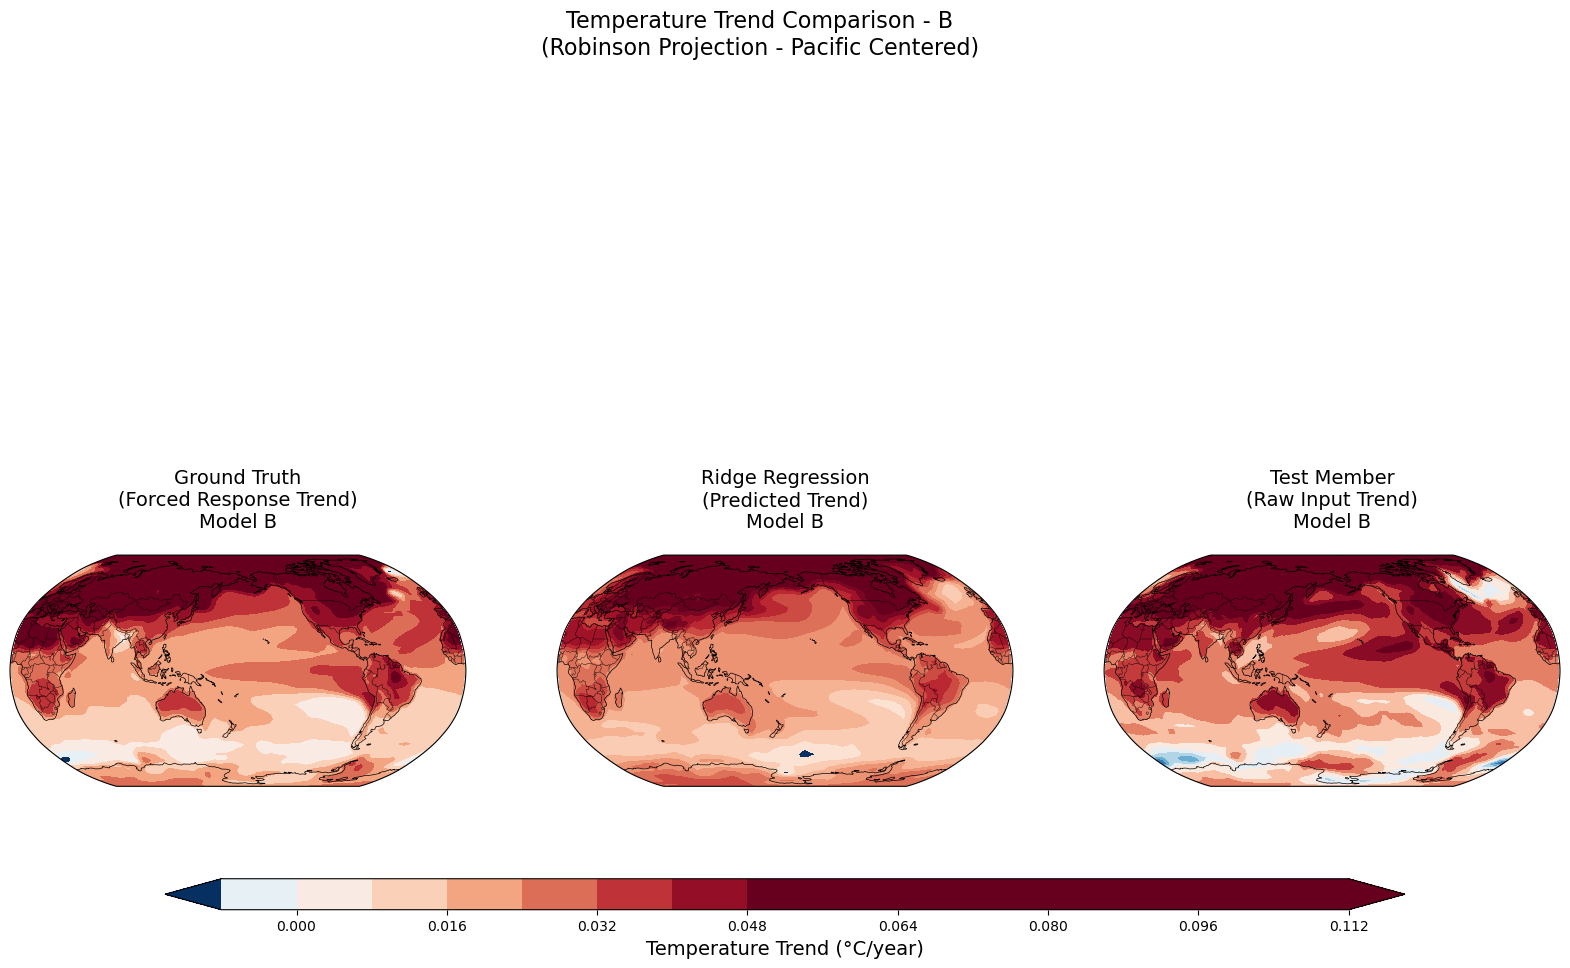

In [49]:
# Display Robinson projections for comparison
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# First, let's compute the trend of the test member (raw input data)
trend_test_member = np.zeros((x_test_yearly_torch_tmp.shape[0], x_test_yearly_torch_tmp.shape[2]), dtype=np.float32)
for i in range(x_test_yearly_torch_tmp.shape[0]):
    trend_test_member[i, :] = np.polyfit(np.arange(x_test_yearly_torch_tmp.shape[1]), x_test_yearly_torch_tmp[i, :, :], 1)[0]



def plot_triple_robinson_comparison(trend_forced, trend_ridge, trend_test, longitude, latitude, 
                                  run_idx=0, central_longitude=180, cmap='RdBu_r'):
    """
    Plot three Robinson projections side by side for comparison
    """
    # Reshape all trend data to 2D grids
    trend_forced_2d = trend_forced[run_idx, :].reshape(latitude.shape[0], longitude.shape[0])
    trend_ridge_2d = trend_ridge[run_idx, :].reshape(latitude.shape[0], longitude.shape[0])
    trend_test_2d = trend_test[run_idx, :].reshape(latitude.shape[0], longitude.shape[0])
    
    # Create meshgrid for plotting
    lon_2d, lat_2d = np.meshgrid(longitude, latitude)
    
    # Set common color limits based on forced response
    vmax = 0.05
    vmin = -0.05
    
    # Create figure with three subplots
    fig = plt.figure(figsize=(20, 12))
    
    # 1. Ground Truth (Forced Response)
    ax1 = fig.add_subplot(131, projection=ccrs.Robinson(central_longitude=central_longitude))
    ax1.set_global()
    ax1.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax1.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax1.add_feature(cfeature.OCEAN, color='lightblue', alpha=0.3)
    ax1.add_feature(cfeature.LAND, color='lightgray', alpha=0.3)
    
    im1 = ax1.contourf(lon_2d, lat_2d, trend_forced_2d,
                       levels=20, cmap=cmap, vmin=vmin, vmax=vmax,
                       transform=ccrs.PlateCarree(), extend='both')
    ax1.set_title(f'Ground Truth\n(Forced Response Trend)\nModel {lst_test_name[run_idx]}', 
                  fontsize=14, pad=20)
    
    # 2. Ridge Regression Prediction
    ax2 = fig.add_subplot(132, projection=ccrs.Robinson(central_longitude=central_longitude))
    ax2.set_global()
    ax2.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax2.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax2.add_feature(cfeature.OCEAN, color='lightblue', alpha=0.3)
    ax2.add_feature(cfeature.LAND, color='lightgray', alpha=0.3)
    
    im2 = ax2.contourf(lon_2d, lat_2d, trend_ridge_2d,
                       levels=20, cmap=cmap, vmin=vmin, vmax=vmax,
                       transform=ccrs.PlateCarree(), extend='both')
    ax2.set_title(f'Ridge Regression\n(Predicted Trend)\nModel {lst_test_name[run_idx]}', 
                  fontsize=14, pad=20)
    
    # 3. Test Member (Raw Input)
    ax3 = fig.add_subplot(133, projection=ccrs.Robinson(central_longitude=central_longitude))
    ax3.set_global()
    ax3.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax3.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax3.add_feature(cfeature.OCEAN, color='lightblue', alpha=0.3)
    ax3.add_feature(cfeature.LAND, color='lightgray', alpha=0.3)
    
    im3 = ax3.contourf(lon_2d, lat_2d, trend_test_2d,
                       levels=20, cmap=cmap, vmin=vmin, vmax=vmax,
                       transform=ccrs.PlateCarree(), extend='both')
    ax3.set_title(f'Test Member\n(Raw Input Trend)\nModel {lst_test_name[run_idx]}', 
                  fontsize=14, pad=20)
    
    # Add common colorbar
    cbar = fig.colorbar(im1, ax=[ax1, ax2, ax3], orientation='horizontal',
                       pad=0.1, shrink=0.8, aspect=40)
    cbar.set_label('Temperature Trend (°C/year)', fontsize=14)
  
    plt.suptitle(f'Temperature Trend Comparison - {lst_test_name[run_idx]}\n(Robinson Projection - Pacific Centered)', 
                 fontsize=16, y=0.95)
    # plt.tight_layout()
    plt.show()
    
    # return fig

plt.close('all')  # Close any previous plots

# Display comparisons for the first test case (run_idx=0)
print("Displaying triple comparison (Ground Truth vs Ridge Prediction vs Test Member):")
plot_triple_robinson_comparison(trend_forced_response, trend_pred_weighted_low_rank, trend_test_member, 
                               longitude, latitude, run_idx=0, central_longitude=180)